# El azufre que en Marte no debería estar suelto

Marte tiene azufre por todas partes. Siempre agarrado a otra cosa: pegado a calcio, a magnesio, a hierro. Sulfatos y sulfuros.

En el valle de Gediz, una rueda de Curiosity partió una piedra clara del tamaño de un puño. Adentro no había sulfato. Había azufre elemental — el amarillo de toda la vida, el de las cabezas de fósforo.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *A native sulfur deposit in Gale crater, Mars* — VanBommel et al., *Science* 393(6813), 820-825 (2026)
**DOI:** [10.1126/science.adu5501](https://doi.org/10.1126/science.adu5501)
**Datos:** Data S1 y S2 del material suplementario — 26 análisis del espectrómetro APXS del rover
**Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-22-azufre-nativo-gale-marte/notebook.ipynb)

## Dónde miró el rover, y con qué

Gediz Vallis es un canal que baja por la ladera del monte Sharp, dentro del cráter Gale. Curiosity llegó ahí unos 4.200 soles después de aterrizar — más de once años terrestres manejando cuesta arriba.

En el suelo del valle hay un parche triangular de unos 2.100 m² sembrado de piedras claras, casi todas de guijarro a canto (64 a 256 mm). Están dentro de un cañón sinuoso que corta al menos 10 m en la roca madre a lo largo de unos 700 m de pendiente.

El rover les apuntó el APXS: un espectrómetro que dispara partículas alfa y rayos X contra la roca y lee los rayos X que la roca devuelve. Cada elemento responde en su propia energía, así que el espectro es una huella de composición. Entre los soles 4.196 y 4.318 hizo **26 análisis**: **10 sobre cinco piedras claras** y 16 sobre las rocas vecinas del mismo valle.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
OBJETIVO_CLARO   = 'Snow_Lakes'      # piedra clara del depósito (sol 4.202)
OBJETIVO_VECINO  = 'Rixford_Pass'    # roca vecina de Gediz Vallis (sol 4.199)
GRUPO_AZUFRE     = 'Snow_Lakes'      # etiqueta del grupo de piedras claras en el CSV
S_KA_EV          = 2307              # energía teórica de la línea S Ka
VENTANA_PICO_EV  = 100               # semiancho para buscar el pico (eV)

FUENTE = 'Fuente: VanBommel et al. (2026), Science | Datos: Data S1-S2 del suplementario'
COLOR_DATOS      = '#2563EB'   # piedras claras (azufre)
COLOR_ALERTA     = '#DC2626'   # contraste
COLOR_REFERENCIA = '#D97706'   # valores de referencia del paper
COLOR_SECUNDARIO = '#059669'
COLOR_CONTEXTO   = '#BBBBBB'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-08-22-azufre-nativo-gale-marte'

# Estilo CaM (local -> /tmp -> GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)
os.makedirs('datos', exist_ok=True)
for archivo in ['composicion_apxs.csv', 'espectros_apxs.csv', 'espectros_metadatos.csv']:
    if not os.path.exists(f'datos/{archivo}'):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{archivo}', f'datos/{archivo}')

comp = pd.read_csv('datos/composicion_apxs.csv')
espec = pd.read_csv('datos/espectros_apxs.csv')
meta = pd.read_csv('datos/espectros_metadatos.csv')

# Dos objetivos quedan fuera de toda estadistica de la campana:
# - 'Atmosphere' es un espectro de referencia acumulado, no una medicion individual
#   (sol y temp_cabezal traen -99 como centinela, y el tiempo es acumulado).
# - 'Sourdough_RP' es del sol 673, anterior a Gediz Vallis y sin fila de composicion.
meta_rocas = meta[meta.objetivo.isin(comp.objetivo)].copy()

def es(x, dec=2):
    """Formato numérico español: miles con punto, decimales con coma."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', '\u00a7').replace('.', ',').replace('\u00a7', '.')

azufre = comp[comp.grupo == GRUPO_AZUFRE]
otras  = comp[comp.grupo != GRUPO_AZUFRE]

print(f'Análisis APXS con composición : {len(comp)}')
print(f'  piedras claras (grupo {GRUPO_AZUFRE}) : {len(azufre)} análisis sobre 5 piedras')
print(f'  resto de rocas de Gediz Vallis        : {len(otras)} análisis')
print(f'Soles cubiertos               : {comp.sol.min()} - {comp.sol.max()}')
print(f'Espectros crudos              : {espec.objetivo.nunique()} objetivos x {espec.canal.nunique()} canales')
print(f'Rango de energía              : {espec.energia_ev.min():.0f} - {espec.energia_ev.max():.0f} eV')
print(f'Tiempo de integración (rocas) : {meta_rocas.tiempo_integracion_s.min():.0f} - '
      f'{meta_rocas.tiempo_integracion_s.max():.0f} s '
      f'({meta_rocas.tiempo_integracion_s.max()/meta_rocas.tiempo_integracion_s.min():.1f}x)')
print()
# El APXS normaliza los oxidos a ~100 wt%; el residuo son las trazas en ppm.
oxidos = [c for c in comp.columns if c.endswith('_pct')]
suma = comp[oxidos].sum(axis=1)
print(f'Suma de óxidos por análisis   : {suma.min():.2f} - {suma.max():.2f} wt%')
print()
print('ATENCIÓN — la columna nota del CSV, en las piedras claras, dice literalmente:')
for n in azufre.nota.unique():
    print(f'   "{n}"')

Análisis APXS con composición : 26
  piedras claras (grupo Snow_Lakes) : 10 análisis sobre 5 piedras
  resto de rocas de Gediz Vallis        : 16 análisis
Soles cubiertos               : 4196 - 4318
Espectros crudos              : 28 objetivos x 1024 canales
Rango de energía              : 449 - 25636 eV
Tiempo de integración (rocas) : 2351 - 14400 s (6.1x)

Suma de óxidos por análisis   : 99.66 - 99.99 wt%

ATENCIÓN — la columna nota del CSV, en las piedras claras, dice literalmente:
   "Composition derived assuming SO3"
   "Composition derived assuming SO3, ChemCam LIBS before APXS"


## Aquí está.

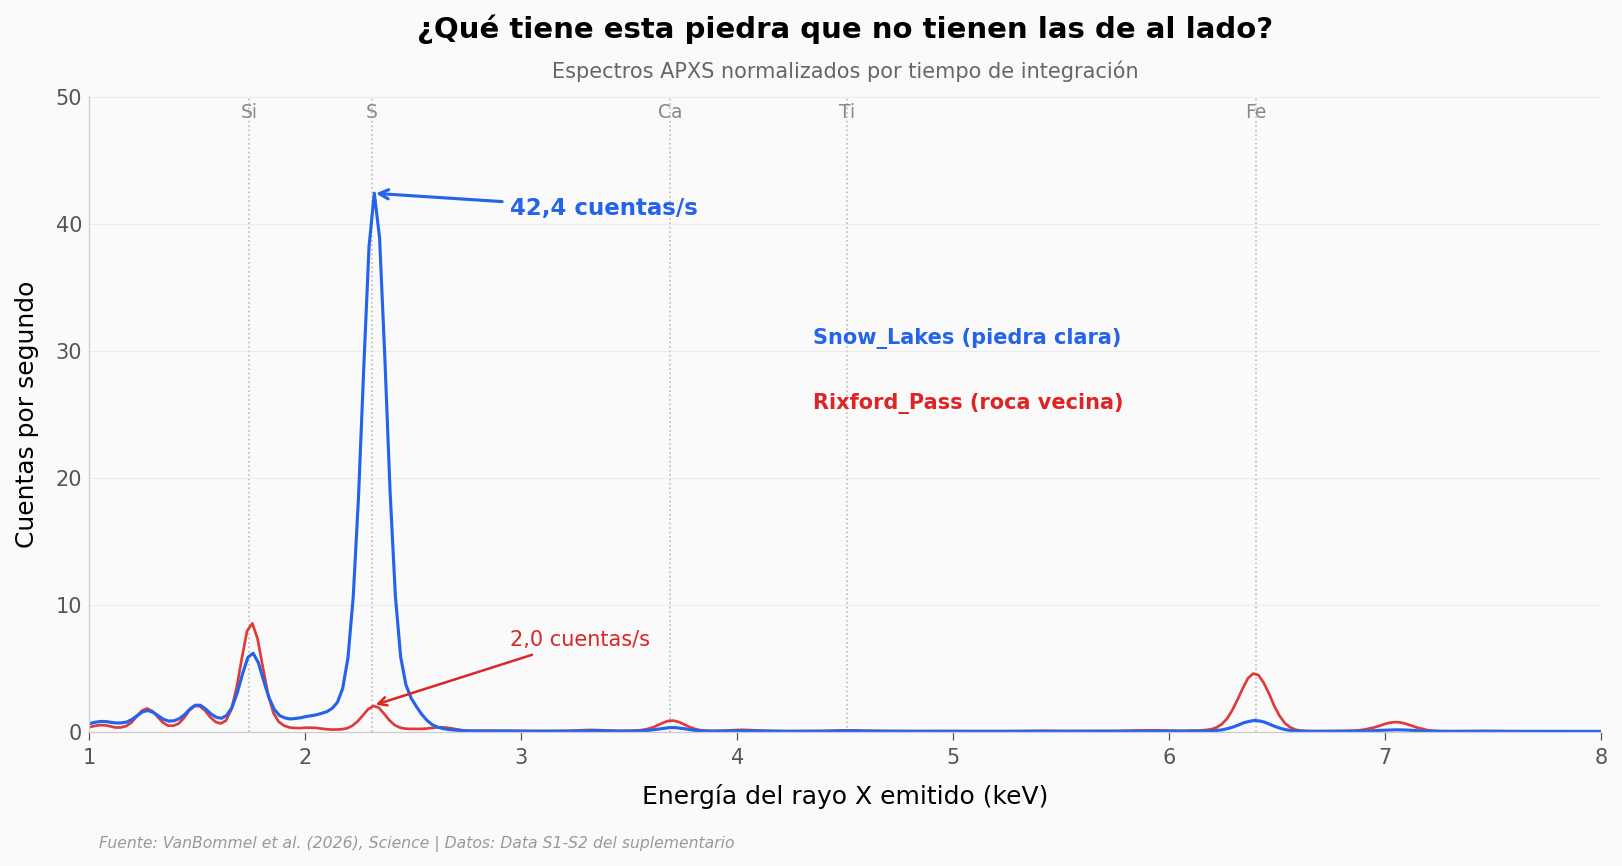

Pico S Ka en Snow_Lakes     :  42.398 cuentas/s
Pico S Ka en Rixford_Pass   :   2.013 cuentas/s
Razón entre los dos           : 21.1x

Snow_Lakes     : S Ka =  42.40 cps | pico elemental más alto fuera del S =  6.16 cps a 1758 eV | S/otro = 6.88x
Rixford_Pass   : S Ka =   2.01 cps | pico elemental más alto fuera del S =  8.52 cps a 1754 eV | S/otro = 0.24x


In [2]:
# ── Grafica hero: el espectro de una piedra clara vs una roca vecina ──
# Los tiempos de integración de la campaña van de 2.351 a 14.400 s (6,1x): superponer
# cuentas crudas haría que el objetivo mirado más rato pareciera el más rico. Usamos cps.
def espectro(nombre):
    s = espec[espec.objetivo == nombre].sort_values('energia_ev')
    return s.energia_ev.to_numpy() / 1000.0, s.cuentas_por_segundo.to_numpy()

e_claro, y_claro = espectro(OBJETIVO_CLARO)
e_vecino, y_vecino = espectro(OBJETIVO_VECINO)

def pico_cps(nombre, energia_ev, ventana=VENTANA_PICO_EV):
    s = espec[espec.objetivo == nombre]
    w = s[(s.energia_ev > energia_ev - ventana) & (s.energia_ev < energia_ev + ventana)]
    return w.cuentas_por_segundo.max()

s_claro = pico_cps(OBJETIVO_CLARO, S_KA_EV)
s_vecino = pico_cps(OBJETIVO_VECINO, S_KA_EV)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(e_vecino, y_vecino, color=COLOR_ALERTA, linewidth=1.3, alpha=0.9)
ax.plot(e_claro, y_claro, color=COLOR_DATOS, linewidth=1.5)

ax.set_xlim(1.0, 8.0)
ax.set_ylim(0, max(y_claro.max(), y_vecino.max()) * 1.18)

# Etiquetas inline (reemplazan la caja de leyenda)
ax.text(4.35, s_claro * 0.72, f'{OBJETIVO_CLARO} (piedra clara)', fontsize=10,
        color=COLOR_DATOS, fontweight='bold')
ax.text(4.35, s_claro * 0.60, f'{OBJETIVO_VECINO} (roca vecina)', fontsize=10,
        color=COLOR_ALERTA, fontweight='bold')

# Lineas de emision de referencia (valores de tabla)
lineas = [(1.740, 'Si'), (2.307, 'S'), (3.691, 'Ca'), (4.511, 'Ti'), (6.403, 'Fe')]
for ev, simbolo in lineas:
    ax.axvline(ev, color=COLOR_CONTEXTO, linewidth=0.8, linestyle=':', zorder=1)
    ax.text(ev, ax.get_ylim()[1] * 0.99, simbolo, fontsize=9, color='#888888',
            ha='center', va='top')

ax.annotate(f'{es(s_claro, 1)} cuentas/s',
            xy=(2.307, s_claro), xytext=(2.95, s_claro * 0.96),
            fontsize=11, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))
ax.annotate(f'{es(s_vecino, 1)} cuentas/s',
            xy=(2.307, s_vecino), xytext=(2.95, max(y_claro) * 0.16),
            fontsize=10, color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

ax.set_xlabel('Energía del rayo X emitido (keV)')
ax.set_ylabel('Cuentas por segundo')
ax.set_title('¿Qué tiene esta piedra que no tienen las de al lado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Espectros APXS normalizados por tiempo de integración',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_hero.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pico S Ka en {OBJETIVO_CLARO:15s}: {s_claro:7.3f} cuentas/s')
print(f'Pico S Ka en {OBJETIVO_VECINO:15s}: {s_vecino:7.3f} cuentas/s')
print(f'Razón entre los dos           : {s_claro/s_vecino:.1f}x')

# ¿Domina el azufre la jerarquia de lineas? Comparamos S Ka contra el pico mas alto
# que quede en la ventana elemental (1-8 keV) fuera del azufre. Restringimos a esa
# ventana a proposito: por encima de 20 keV el espectro tiene la dispersion de la
# fuente de excitacion, que no es una linea de emision de la roca.
print()
for nombre in [OBJETIVO_CLARO, OBJETIVO_VECINO]:
    s = espec[espec.objetivo == nombre]
    elemental = s[(s.energia_ev > 1000) & (s.energia_ev < 8000)]
    fuera = elemental[(elemental.energia_ev < S_KA_EV - 300) |
                      (elemental.energia_ev > S_KA_EV + 300)]
    alt = fuera.loc[fuera.cuentas_por_segundo.idxmax()]
    sk = pico_cps(nombre, S_KA_EV)
    print(f'{nombre:15s}: S Ka = {sk:6.2f} cps | pico elemental más alto fuera del S = '
          f'{alt.cuentas_por_segundo:5.2f} cps a {alt.energia_ev:.0f} eV '
          f'| S/otro = {sk/alt.cuentas_por_segundo:.2f}x')

## Lo que hay que leer con cuidado

El azufre responde a 2,307 keV, y ahí la piedra clara devuelve unas 21 veces más rayos X por segundo que la roca de al lado. No es cosa de ese par: el promedio del grupo de piedras claras (36,96 cuentas/s) es 22 veces el de las rocas vecinas (1,68). En el silicio, el calcio y el hierro pasa lo contrario: la curva azul se aplana justo donde la roja tiene sus picos.

Lo que cambia no es solo la altura del azufre: cambia el orden. En `Snow_Lakes` la línea del azufre es la más alta del espectro, casi 7 veces la siguiente. En `Rixford_Pass` la más alta es la del silicio, y el azufre queda en una cuarta parte de ella. No es que la piedra clara tenga *más* azufre encima de una roca normal — es que casi todo lo demás desapareció.

Y aquí está la trampa que hay que nombrar antes de seguir.

> El APXS no mide moléculas: mide **elementos**. Cuando detecta azufre, la calibración lo reporta **como si fuera trióxido de azufre (SO₃)**, porque en Marte el azufre casi siempre viene en sulfatos. La columna del CSV lo dice sin rodeos: *«Composition derived assuming SO₃»*.
>
> Es una convención de la calibración, no un resultado. **La conclusión del paper es la contraria:** lo que hay debajo es azufre elemental, S⁰. Así que cuando en las gráficas siguientes veamos «83 wt%» (wt% = porcentaje en peso), eso significa *azufre reportado como si fuera sulfato* — nunca «la piedra es 83% sulfato».

Con esa advertencia puesta, la pregunta ya no es cuánto azufre hay. Es de qué está agarrado.

## El argumento de lo que falta

Un sulfato necesita un catión que lo sostenga: calcio, magnesio, hierro, potasio. En el cráter Gale los sulfatos son justamente esos — yeso, sulfato de magnesio, jarosita.

Si estas piedras fueran sulfato, los cationes tendrían que estar. Veamos.

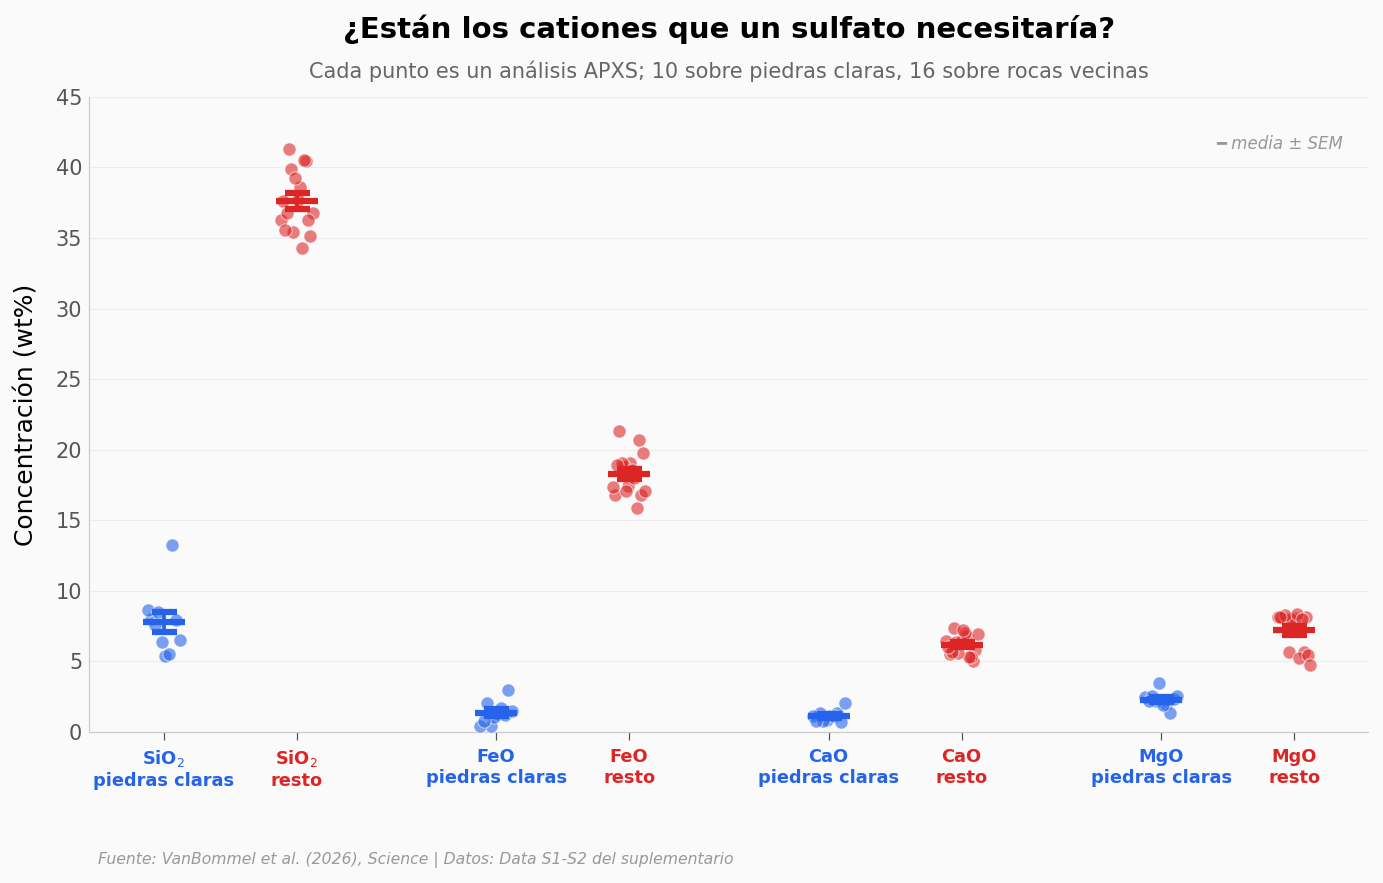

óxido      claras    resto   razón   d Cohen     p (M-W)
SiO2         7.78    37.61    0.21     13.65    2.78e-05
FeO          1.36    18.28    0.07     13.23    2.79e-05
CaO          1.12     6.18    0.18      7.91    2.78e-05
MgO          2.29     7.20    0.32      4.45    2.78e-05

n = 10 análisis sobre piedras claras vs 16 sobre rocas vecinas.
Mann-Whitney U (no paramétrico): Shapiro-Wilk rechaza normalidad en el grupo
de piedras claras (p = 0.034 sobre SO3).


In [3]:
# ── Los cuatro oxidos que un sulfato necesitaria tener ──
np.random.seed(42)

elementos = [('SiO2_pct', 'SiO$_2$'), ('FeO_pct', 'FeO'),
             ('CaO_pct', 'CaO'), ('MgO_pct', 'MgO')]
posiciones = [0, 1, 2.5, 3.5, 5, 6, 7.5, 8.5]

fig, ax = plt.subplots(figsize=(11, 5.5))
xticks, xlabels, xcolors = [], [], []
resumen = []

for k, (col, etiqueta) in enumerate(elementos):
    for j, (datos, nombre, color) in enumerate(
            [(azufre[col], 'piedras claras', COLOR_DATOS),
             (otras[col], 'resto', COLOR_ALERTA)]):
        pos = posiciones[2 * k + j]
        vals = datos.to_numpy()
        n = len(vals)
        x_strip = np.linspace(pos - 0.12, pos + 0.12, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=40, alpha=0.6,
                   edgecolors='white', linewidths=0.5, zorder=5)
        media = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(pos, media, yerr=sem, fmt='_', color=color, markersize=20,
                    markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
        xticks.append(pos)
        xlabels.append(f'{etiqueta}\n{nombre}')
        xcolors.append(color)
    a, b = azufre[col], otras[col]
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    d = abs(a.mean() - b.mean()) / sp
    p = stats.mannwhitneyu(a, b, alternative='two-sided').pvalue
    resumen.append((etiqueta.replace('$_2$', '2'), a.mean(), b.mean(), a.mean() / b.mean(), d, p))

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=8.5, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), xcolors):
    tick.set_color(color)
ax.set_ylabel('Concentración (wt%)')
ax.set_ylim(0, 45)
ax.set_title('¿Están los cationes que un sulfato necesitaría?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un análisis APXS; 10 sobre piedras claras, 16 sobre rocas vecinas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.94, '\u2501 media \u00b1 SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/oxidos_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{"óxido":8s} {"claras":>8s} {"resto":>8s} {"razón":>7s} {"d Cohen":>9s} {"p (M-W)":>11s}')
for et, ma, mo, r, d, p in resumen:
    print(f'{et:8s} {ma:8.2f} {mo:8.2f} {r:7.2f} {d:9.2f} {p:11.2e}')
print()
print(f'n = {len(azufre)} análisis sobre piedras claras vs {len(otras)} sobre rocas vecinas.')
print('Mann-Whitney U (no paramétrico): Shapiro-Wilk rechaza normalidad en el grupo')
print(f'de piedras claras (p = {stats.shapiro(azufre["SO3_pct"]).pvalue:.3f} sobre SO3).')

## Una segunda huella, que no depende de la primera

Los cationes escasean, sí. Pero un escéptico diría que eso también pasaría con un sulfato raro, uno que todavía no hemos visto en Marte.

Por suerte el APXS deja otra pista, y es de otra naturaleza. Los rayos X que rebotan en la roca lo hacen de dos maneras: algunos salen con la misma energía con que entraron (dispersión elástica, o Rayleigh) y otros pierden un poco en el camino (dispersión inelástica, o Compton). **La razón entre las dos depende de qué tan pesados sean los átomos de la muestra.** Mucho oxígeno y otros elementos ligeros empujan la razón hacia arriba.

Un sulfato es azufre *más tres oxígenos por cada azufre*. Azufre elemental no tiene ninguno. Los dos deberían dar razones distintas — y esta medida no usa ni una sola de las concentraciones de la gráfica anterior.

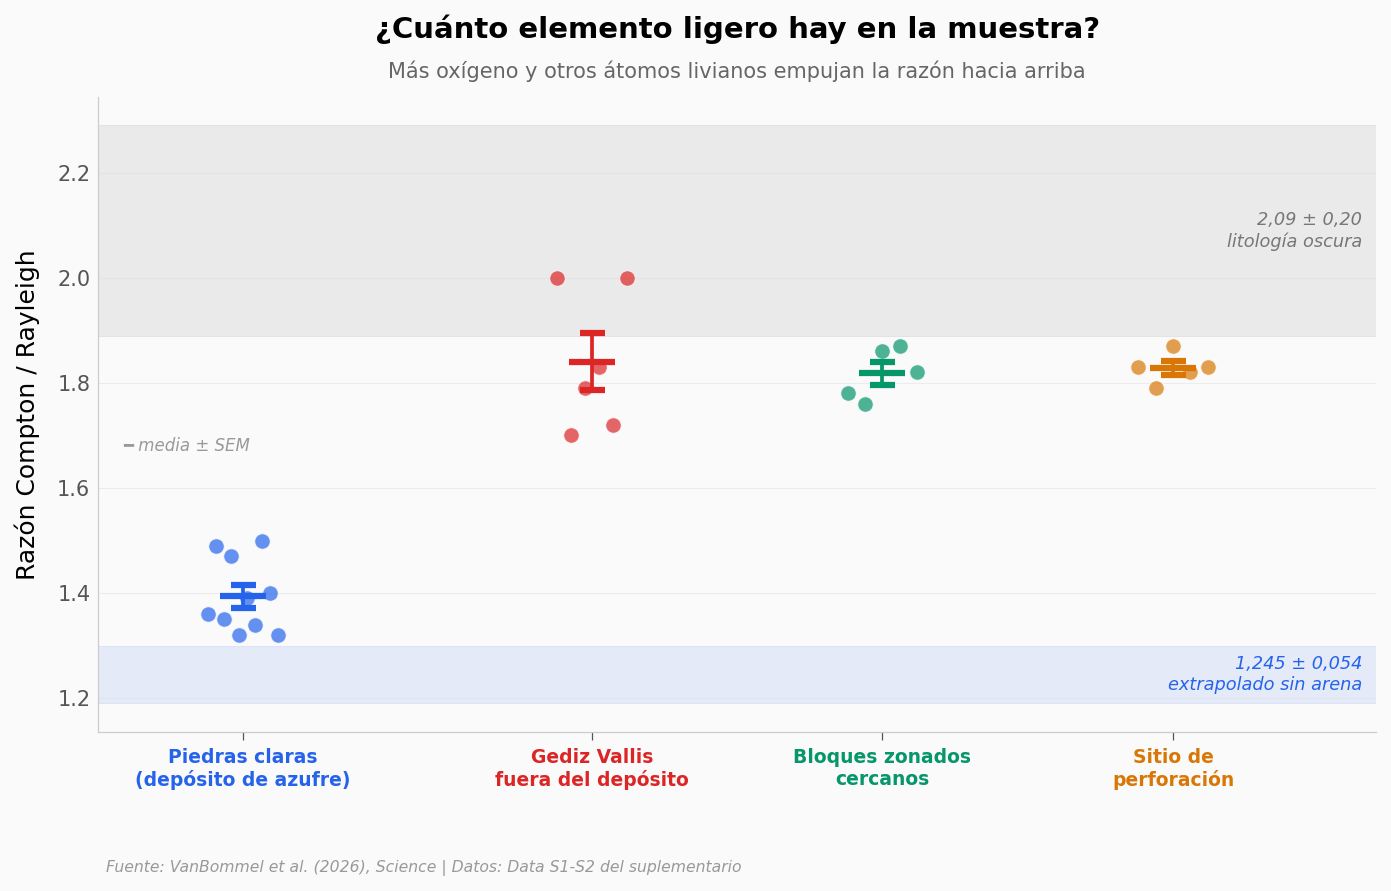

Piedras claras : media 1.394  (rango 1.32 - 1.50, n = 10)
Resto de rocas : media 1.829  (rango 1.70 - 2.00, n = 16)
d de Cohen = 5.60   Mann-Whitney p = 2.71e-05

Nuestras medidas incluyen la arena y el polvo que cubren las piedras, así que
quedan por encima del 1,245 que el paper extrapola para la piedra limpia.
El 1,39 medido NO es "el valor del azufre puro".


In [4]:
# ── Compton/Rayleigh: la firma independiente ──
# El paper extrapola dos valores de referencia quitando el aporte de arena y polvo:
CR_CLARO_PAPER, CR_CLARO_ERR = 1.245, 0.054   # piedra clara sin arena
CR_OSCURO_PAPER, CR_OSCURO_ERR = 2.09, 0.20   # litología oscura y picada

np.random.seed(42)
orden = [('Snow_Lakes', 'Piedras claras\n(depósito de azufre)', COLOR_DATOS),
         ('GVR_other', 'Gediz Vallis\nfuera del depósito', COLOR_ALERTA),
         ('Gray_Peak', 'Bloques zonados\ncercanos', COLOR_SECUNDARIO),
         ('Mammoth_Lakes', 'Sitio de\nperforación', COLOR_REFERENCIA)]
posiciones = [0, 1.2, 2.2, 3.2]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axhspan(CR_CLARO_PAPER - CR_CLARO_ERR, CR_CLARO_PAPER + CR_CLARO_ERR,
           color=COLOR_DATOS, alpha=0.10, zorder=1)
ax.axhspan(CR_OSCURO_PAPER - CR_OSCURO_ERR, CR_OSCURO_PAPER + CR_OSCURO_ERR,
           color=COLOR_CONTEXTO, alpha=0.25, zorder=1)
ax.text(3.85, CR_CLARO_PAPER, f'{es(CR_CLARO_PAPER, 3)} \u00b1 {es(CR_CLARO_ERR, 3)}\nextrapolado sin arena',
        fontsize=8.5, color=COLOR_DATOS, va='center', ha='right', style='italic')
ax.text(3.85, CR_OSCURO_PAPER, f'{es(CR_OSCURO_PAPER, 2)} \u00b1 {es(CR_OSCURO_ERR, 2)}\nlitología oscura',
        fontsize=8.5, color='#777777', va='center', ha='right', style='italic')

for pos, (grupo, etiqueta, color) in zip(posiciones, orden):
    vals = comp.loc[comp.grupo == grupo, 'compton_rayleigh'].to_numpy()
    n = len(vals)
    x_strip = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=55, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color, markersize=22,
                markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

ax.set_xticks(posiciones)
ax.set_xticklabels([e for _, e, _ in orden], fontsize=9, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), orden):
    tick.set_color(color)
ax.set_xlim(-0.5, 3.9)
ax.set_ylabel('Razón Compton / Rayleigh')
ax.set_title('¿Cuánto elemento ligero hay en la muestra?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Más oxígeno y otros átomos livianos empujan la razón hacia arriba',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.02, 0.45, '\u2501 media \u00b1 SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='left', va='center', style='italic')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/compton_rayleigh.png', dpi=200, bbox_inches='tight')
plt.show()

a = azufre['compton_rayleigh']; b = otras['compton_rayleigh']
na, nb = len(a), len(b)
sp = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
p = stats.mannwhitneyu(a, b, alternative='two-sided').pvalue
print(f'Piedras claras : media {a.mean():.3f}  (rango {a.min():.2f} - {a.max():.2f}, n = {na})')
print(f'Resto de rocas : media {b.mean():.3f}  (rango {b.min():.2f} - {b.max():.2f}, n = {nb})')
print(f'd de Cohen = {abs(a.mean()-b.mean())/sp:.2f}   Mann-Whitney p = {p:.2e}')
print()
print('Nuestras medidas incluyen la arena y el polvo que cubren las piedras, así que')
print(f'quedan por encima del {es(CR_CLARO_PAPER, 3)} que el paper extrapola para la piedra limpia.')
print('El 1,39 medido NO es "el valor del azufre puro".')

## ¿Qué tan raro es esto dentro del valle?

Curiosity lleva más de una década midiendo rocas, pero lo que cabe en esta gráfica son los 26 análisis de la campaña de Gediz Vallis. Miremos dónde caen estas piedras entre sus propias vecinas.

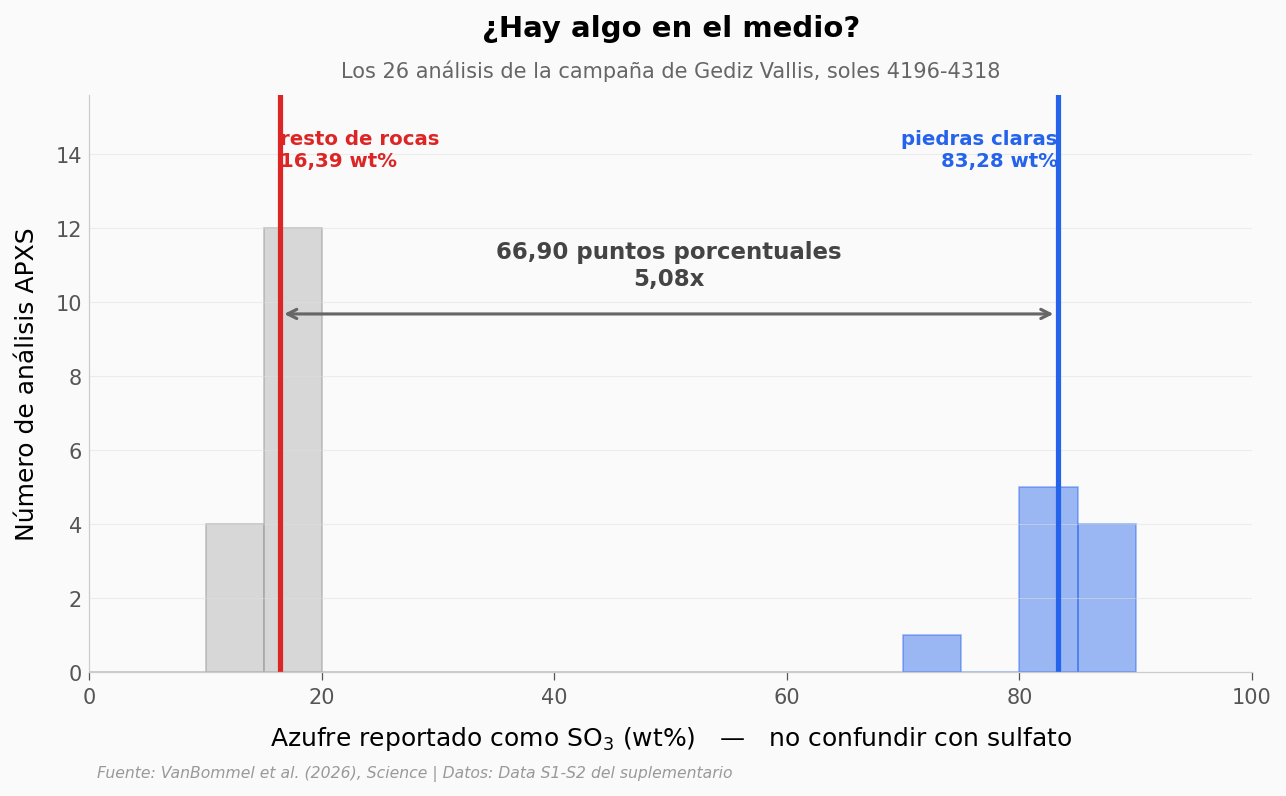

Piedras claras : 72.08 - 88.08 wt% (media 83.28, mediana 83.06, IQR 82.43 - 86.49)
Resto de rocas : 10.20 - 19.80 wt% (media 16.39, mediana 17.48, IQR 15.51 - 18.29)
Ningún análisis cae entre 19.80 y 72.08 wt%: un hueco de 52.28 puntos.
d de Cohen = 18.87   Mann-Whitney p = 2.79e-05


In [5]:
# ── Histograma de anomalia: donde cae el azufre de las piedras claras ──
vals = comp['SO3_pct'].to_numpy()
m_azufre = azufre['SO3_pct'].mean()
m_otras = otras['SO3_pct'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, 95, 5)
n, bins_out, patches = ax.hist(vals, bins=bins, color=COLOR_CONTEXTO, alpha=0.55,
                               edgecolor='#999999', linewidth=0.8)
# Colorear las barras que caen en el rango de las piedras claras
for parche, borde in zip(patches, bins_out[:-1]):
    if borde >= azufre['SO3_pct'].min() - 5:
        parche.set_facecolor(COLOR_DATOS)
        parche.set_alpha(0.45)
        parche.set_edgecolor(COLOR_DATOS)

y_max = n.max() * 1.30
ax.set_ylim(0, y_max)
ax.set_xlim(0, 100)
ax.axvline(m_otras, color=COLOR_ALERTA, linewidth=2.5)
ax.axvline(m_azufre, color=COLOR_DATOS, linewidth=2.5)
ax.annotate('', xy=(m_azufre, y_max * 0.62), xytext=(m_otras, y_max * 0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((m_azufre + m_otras) / 2, y_max * 0.67,
        f'{es(m_azufre - m_otras, 2)} puntos porcentuales\n{es(m_azufre / m_otras, 2)}x',
        fontsize=11, fontweight='bold', color='#444444', ha='center')
ax.text(m_otras, y_max * 0.94, f'resto de rocas\n{es(m_otras, 2)} wt%', fontsize=9.5,
        color=COLOR_ALERTA, fontweight='bold', ha='left', va='top')
ax.text(m_azufre, y_max * 0.94, f'piedras claras\n{es(m_azufre, 2)} wt%', fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', ha='right', va='top')

ax.set_xlabel('Azufre reportado como SO$_3$ (wt%)   \u2014   no confundir con sulfato')
ax.set_ylabel('Número de análisis APXS')
ax.set_title('¿Hay algo en el medio?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Los {len(comp)} análisis de la campaña de Gediz Vallis, soles {comp.sol.min()}-{comp.sol.max()}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

hueco_bajo = otras['SO3_pct'].max()
hueco_alto = azufre['SO3_pct'].min()
print(f'Piedras claras : {azufre["SO3_pct"].min():.2f} - {azufre["SO3_pct"].max():.2f} wt% '
      f'(media {m_azufre:.2f}, mediana {azufre["SO3_pct"].median():.2f}, '
      f'IQR {azufre["SO3_pct"].quantile(.25):.2f} - {azufre["SO3_pct"].quantile(.75):.2f})')
print(f'Resto de rocas : {otras["SO3_pct"].min():.2f} - {otras["SO3_pct"].max():.2f} wt% '
      f'(media {m_otras:.2f}, mediana {otras["SO3_pct"].median():.2f}, '
      f'IQR {otras["SO3_pct"].quantile(.25):.2f} - {otras["SO3_pct"].quantile(.75):.2f})')
print(f'Ningún análisis cae entre {hueco_bajo:.2f} y {hueco_alto:.2f} wt%: '
      f'un hueco de {hueco_alto - hueco_bajo:.2f} puntos.')
a, b = azufre['SO3_pct'], otras['SO3_pct']
sp = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) / (len(a)+len(b)-2))
print(f'd de Cohen = {abs(a.mean()-b.mean())/sp:.2f}   '
      f'Mann-Whitney p = {stats.mannwhitneyu(a, b, alternative="two-sided").pvalue:.2e}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las piedras claras tienen muchísimo más azufre que las rocas vecinas | ✅ | 83,28 vs 16,39 wt% de media (reportado como SO₃): +66,90 puntos, 5,08x. d de Cohen = 18,87; Mann-Whitney p = 2,79e-05. n = 10 análisis sobre 5 piedras vs 16 análisis vecinos |
| El pico de azufre domina el espectro de las piedras claras | ✅ | En `Snow_Lakes` la línea S Kα llega a 42,40 cuentas/s y es 6,88 veces el pico elemental más alto que queda fuera del azufre (Si, 6,16 cuentas/s). En `Rixford_Pass` el orden se invierte: manda el silicio (8,52 cuentas/s) y el azufre se queda en 2,01, un 0,24 de esa altura. Comparación hecha en la ventana de 1 a 8 keV y con los espectros normalizados a cuentas por segundo |
| A las piedras claras les faltan los cationes de un sulfato | ✅ | CaO 1,12 vs 6,18 wt% (0,18x, d = 7,91) · MgO 2,29 vs 7,20 (0,32x, d = 4,45) · FeO 1,36 vs 18,28 (0,07x, d = 13,23) · SiO₂ 7,78 vs 37,61 (0,21x, d = 13,65). Todos con p < 1e-04 |
| La dispersión Compton/Rayleigh apunta a poco elemento ligero | ✅ | 1,39 vs 1,83 de media (d = 5,60; p = 2,71e-05). Es una medida independiente de las concentraciones anteriores |
| El material es **azufre elemental (S⁰) y no sulfato** | ⚠️ | Es la conclusión del paper, y la sostienen cuatro líneas de evidencia (tasas de conteo, dispersión elástica/inelástica, escasez de cationes, gradiente multipunto). **El APXS no puede leer la forma química directamente:** mide elementos y reporta el azufre como SO₃ por convención de calibración. Los datos que están en este notebook son *compatibles* con S⁰ y descartan un sulfato común — no son una medición de la molécula |
| El depósito se formó ahí mismo, no llegó rodando | ⚠️ | El abstract dice *«appears to have formed in place»*. Es una lectura de la geología del cañón, no una medición; el APXS no la toca |
| El azufre vino de vapor magmático atrapado en la criosfera | ⚠️ | El abstract dice *«We propose»*. Es la hipótesis de los autores sobre el origen. Ningún dato de este notebook la prueba ni la contradice: aquí solo hay composición |

> **Limitaciones**
>
> - **Diseño observacional.** Curiosity midió lo que había; nadie preparó muestras ni manipuló condiciones. Los contrastes entre grupos son reales, pero de aquí no sale ninguna causa.
> - **El número de piedras viene del paper, no del CSV.** Son 5 piedras y 10 análisis APXS; el archivo trae 10 filas con 6 nombres base distintos y no incluye el mapeo objetivo → piedra.
> - **Cuentas por segundo no es concentración.** La altura de un pico depende también del polvo, la geometría del contacto y la temperatura del cabezal del detector. Dentro del grupo de azufre el orden de cps no sigue al de SO₃: `Convict_Lake` tiene la concentración más alta (88,08 wt%) y de las tasas de conteo más bajas.
> - **El 1,39 de Compton/Rayleigh no es el valor del azufre limpio.** Nuestras medidas incluyen la arena y el polvo que cubren las piedras. El paper extrapola 1,245 ± 0,054 para la piedra sin arena.
> - **n pequeño, y no del todo independiente.** 26 análisis en total, entre 5 y 10 por grupo. Los tamaños de efecto salen enormes en parte porque los grupos están muy separados y la dispersión dentro de cada uno es baja; con n así, un valor extremo mueve mucho. Y los 26 análisis no son 26 rocas: hay varias medidas sobre el mismo objetivo (`Snow_Lakes` cuatro veces contando sus rásteres, `Convict_Lake` dos, `Gray_Peak` dos, `Loch_Leven` dos, `Mammoth_Lakes` tres), así que los tests tratan como independientes medidas que no lo son. Promediando a una sola cifra por roca (6 claras contra 12 vecinas) el contraste aguanta: SO₃ d = 23,28 con p = 1,08e-04, y Compton/Rayleigh d = 5,34 con p = 8,68e-04.
> - **El p-valor está topado por el tamaño de muestra.** Con 10 análisis contra 16, el número más bajo que Mann-Whitney puede devolver es 2,79e-05, y ahí caen los cinco p de este notebook. Que todos den lo mismo no son cinco confirmaciones independientes: significa que en las cinco variables los dos grupos no se solapan en absoluto. Quien gradúa la evidencia aquí es el tamaño de efecto y el hueco de 52,28 puntos, no el p.
> - **Puede haber una costra que el APXS no vea.** Los autores contemplan un recubrimiento de azufre oxidado de aproximadamente 1 μm de espesor, por debajo de lo que el instrumento resuelve.

## Ahora tú

1. **¿Se sostiene el pico si cambias de piedra?** En la celda 2, cambia `OBJETIVO_CLARO` por `'Lake_Dorothy'`, `'Moonlight_Lake'`, `'Palisade_Glacier'` o `'Cloud_Canyon'` y vuelve a correr la gráfica hero. ¿Cambia la forma del espectro o solo la altura? Pista: mira también `meta[meta.objetivo == OBJETIVO_CLARO]` — el tiempo de integración y la temperatura del cabezal cambian entre objetivos.

2. **¿El bromo también se comporta distinto?** El CSV trae tres elementos traza en ppm (`Ni_ppm`, `Zn_ppm`, `Br_ppm`) que ninguna gráfica de arriba usa. Compara sus distribuciones entre grupos con `comp.groupby('grupo')[['Ni_ppm','Zn_ppm','Br_ppm']].describe()`. ¿Alguno separa los grupos tan limpiamente como el azufre?

3. **¿Qué tan bien calibrado está el espectrómetro?** La energía la derivamos con `E(eV) = ganancia × canal + offset` a partir de `espectros_metadatos.csv`. La celda de abajo compara las líneas de emisión medidas contra sus valores de tabla. ¿Cuánto se desvían, y cómo se compara esa desviación con el ancho del propio pico?

In [6]:
# --- EXPERIMENTA AQUI ---
# ¿Podemos confiar en el eje de energias? Comparamos donde CAE cada linea de emision
# fuerte contra su valor de tabla. La escala de referencia es el FWHM del detector
# (~160-180 eV segun la columna FWHM del CSV de composicion): una desviacion muy por
# debajo del ancho del propio pico no mueve la identificacion del elemento.

lineas_tabla = {'Mg Ka': 1254, 'Si Ka': 1740, 'S Ka': 2307,
                'Ca Ka': 3691, 'Ti Ka': 4511, 'Fe Ka': 6403}
OBJETIVO_CAL = 'Snow_Lakes'   # <-- cambia esto por cualquier objetivo del CSV

sub = espec[espec.objetivo == OBJETIVO_CAL]
print(f'Calibración sobre {OBJETIVO_CAL}')
print(f'{"línea":8s} {"tabla":>8s} {"medido":>9s} {"delta":>8s}')
deltas = []
for nombre, ev in lineas_tabla.items():
    w = sub[(sub.energia_ev > ev - 100) & (sub.energia_ev < ev + 100)]
    medido = w.loc[w.cuentas.idxmax(), 'energia_ev']
    deltas.append(medido - ev)
    print(f'{nombre:8s} {ev:8d} {medido:9.1f} {medido - ev:+8.1f} eV')

fwhm = comp.loc[comp.objetivo == OBJETIVO_CAL, 'FWHM']
print()
print(f'Desviación máxima : {max(abs(d) for d in deltas):.1f} eV')
if len(fwhm):
    print(f'FWHM del detector : {fwhm.iloc[0]:.1f} eV en este objetivo')
    print(f'La desviación es el {max(abs(d) for d in deltas)/fwhm.iloc[0]*100:.0f}% del ancho del pico.')

# Ojo: Cl Ka y Fe Kb son picos debiles, y la ventana de +-100 eV les atrapa vecinos
# mas altos. No sirven para validar la calibracion.

Calibración sobre Snow_Lakes
línea       tabla    medido    delta
Mg Ka        1254    1270.2    +16.2 eV
Si Ka        1740    1758.2    +18.2 eV
S Ka         2307    2319.4    +12.4 eV
Ca Ka        3691    3710.2    +19.2 eV
Ti Ka        4511    4515.4     +4.4 eV
Fe Ka        6403    6394.2     -8.8 eV

Desviación máxima : 19.2 eV
FWHM del detector : 171.1 eV en este objetivo
La desviación es el 11% del ancho del pico.


---

## Fuentes

**Paper**: [A native sulfur deposit in Gale crater, Mars](https://doi.org/10.1126/science.adu5501)  
*Science, 2026-08-20*

**Datos**: [Data S1 and S2 — APXS compositional and spectral measurements (supplementary material)](https://www.science.org/doi/suppl/10.1126/science.adu5501/suppl_file/science.adu5501_data_s1_and_s2.zip)  
*Composición elemental y espectros APXS de 26 análisis en Gediz Vallis*

**Referencias citadas**: [MSL APXS RDR archive — NASA PDS Geosciences Node](https://pds-geosciences.wustl.edu/msl/msl-m-apxs-4_5-rdr-v1/mslapx_1xxx/) · [APXS Spectral Modeling for Native Sulfur on Mars — WUSTL](https://doi.org/10.7936/6rxs-108352)

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*